In [1]:
%run 00setup.ipynb

✅ Setup complete


In [2]:
# Signal output from 03LGBMsignal.ipynb (ranker)
oos = load_df("oos_predictions_ranker", DATA_DIR, fmt="parquet")


prices = load_df("prices_clean", DATA_DIR, fmt="parquet")

# Standardize types/order
oos["date"] = pd.to_datetime(oos["date"])
prices["date"] = pd.to_datetime(prices["date"])

oos = oos.sort_values(["date", "ticker"]).reset_index(drop=True)
prices = prices.sort_values(["date", "ticker"]).reset_index(drop=True)

print("oos:", oos.shape, "| prices:", prices.shape)
print("tickers:", oos["ticker"].nunique(), "dates:", oos["date"].nunique())

oos: (50200, 7) | prices: (71373, 8)
tickers: 20 dates: 2510


In [3]:
price_col = "adj_close"
prices["ret_1d"] = prices.groupby("ticker")[price_col].pct_change()

R = prices.pivot(index="date", columns="ticker", values="ret_1d").sort_index()
R = R.replace([np.inf, -np.inf], np.nan).dropna(how="all")
print("R panel:", R.shape, "| from:", R.index.min(), "to:", R.index.max())

R panel: (3568, 20) | from: 2011-10-21 00:00:00 to: 2025-12-30 00:00:00


In [4]:
# Cell 3 — Build signal score panel S[t, asset]

score_col = "y_pred"
S = oos.pivot(index="date", columns="ticker", values=score_col).sort_index()

common_dates = R.index.intersection(S.index)
R = R.loc[common_dates]
S = S.loc[common_dates]

print("Aligned:", "R", R.shape, "S", S.shape)
print("Backtest range:", common_dates.min(), "to", common_dates.max())
print("Score column used:", score_col)

Aligned: R (2510, 20) S (2510, 20)
Backtest range: 2016-01-04 00:00:00 to 2025-12-24 00:00:00
Score column used: y_pred


In [49]:
# Cell 4 — Helpers: 3-regime selection + constrained weight constructors

from scipy.optimize import minimize

EQUITY_TICKERS = [
    "SPY","QQQ","DIA","IWM","VUG","VTV","USMV","FEZ","EWU","EWJ","EEM"
]

DEFENSIVE_TICKERS = [
    "TLT","IEF","SHY","LQD","GLD","DBC","VNQ","XLU","XLP"
]

def pick_regime_topk(scores: pd.Series, regime: str) -> pd.Index:
    scores = scores.dropna()

    eq_scores = scores[scores.index.isin(EQUITY_TICKERS)].dropna()
    def_scores = scores[scores.index.isin(DEFENSIVE_TICKERS)].dropna()

    if regime == "risk_off":
        return def_scores.nlargest(min(4, len(def_scores))).index

    elif regime == "strong_bull":
        return eq_scores.nlargest(min(4, len(eq_scores))).index

    else:  # normal_risk_on
        selected = []
        if len(eq_scores) > 0:
            selected.extend(eq_scores.nlargest(min(3, len(eq_scores))).index.tolist())
        if len(def_scores) > 0:
            selected.extend(def_scores.nlargest(min(1, len(def_scores))).index.tolist())
        return pd.Index(selected).unique()

def w_equal(top: pd.Index) -> pd.Series:
    w = pd.Series(0.0, index=R.columns)
    if len(top) > 0:
        w.loc[top] = 1.0 / len(top)
    return w

def w_inv_vol(ret_hist: pd.DataFrame, top: pd.Index, eps=1e-8) -> pd.Series:
    w = pd.Series(0.0, index=R.columns)
    if len(top) == 0:
        return w
    vol = ret_hist[top].std(ddof=0).replace(0, np.nan)
    inv = 1.0 / (vol + eps)
    inv = inv.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    if inv.sum() > 0:
        w.loc[top] = inv / inv.sum()
    else:
        w.loc[top] = 1.0 / len(top)
    return w

def score_floor_from_selected(scores: pd.Series, top: pd.Index, floor_frac: float = 0.25) -> float:
    s = scores[top].astype(float)
    s_mean = s.mean()
    s_max = s.max()
    return float(s_mean + floor_frac * (s_max - s_mean))

def w_mean_variance(ret_hist: pd.DataFrame,
                    scores: pd.Series,
                    top: pd.Index,
                    floor_frac: float = 0.25,
                    ridge: float = 1e-3,
                    w_max: float = 0.60) -> pd.Series:
    w = pd.Series(0.0, index=R.columns)
    if len(top) == 0:
        return w

    X = ret_hist[top].dropna(how="any")
    if X.shape[0] < 20:
        return w_equal(top)

    Sigma = np.cov(X.values, rowvar=False, ddof=0)
    Sigma = Sigma + ridge * np.eye(Sigma.shape[0])

    mu = scores[top].astype(float).values
    mu_floor = score_floor_from_selected(scores, top, floor_frac=floor_frac)

    n = len(top)
    x0 = np.ones(n) / n

    def objective(ww):
        return float(ww @ Sigma @ ww)

    constraints = [
        {"type": "eq",   "fun": lambda ww: np.sum(ww) - 1.0},
        {"type": "ineq", "fun": lambda ww: float(mu @ ww - mu_floor)},
    ]
    bounds = [(0.0, w_max)] * n

    res = minimize(
        objective,
        x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 500, "ftol": 1e-9}
    )

    if not res.success:
        return w_inv_vol(X, top)

    ww = np.clip(res.x, 0.0, w_max)
    s = ww.sum()
    if s <= 0:
        return w_equal(top)

    w.loc[top] = ww / s
    return w

def w_cvar(ret_hist: pd.DataFrame,
           scores: pd.Series,
           top: pd.Index,
           alpha: float = 0.95,
           floor_frac: float = 0.25,
           w_max: float = 0.35) -> pd.Series:
    w = pd.Series(0.0, index=R.columns)
    if len(top) == 0:
        return w

    X = ret_hist[top].dropna(how="any")
    if X.shape[0] < 20:
        return w_equal(top)

    Xv = X.values
    mu = scores[top].astype(float).values
    mu_floor = score_floor_from_selected(scores, top, floor_frac=floor_frac)

    n = len(top)
    z0 = np.zeros(n + 1)
    z0[1:] = 1.0 / n

    def objective(z):
        v = z[0]
        ww = z[1:]
        losses = -Xv @ ww
        tail = np.maximum(losses - v, 0.0)
        return float(v + tail.mean() / (1.0 - alpha))

    constraints = [
        {"type": "eq",   "fun": lambda z: np.sum(z[1:]) - 1.0},
        {"type": "ineq", "fun": lambda z: float(mu @ z[1:] - mu_floor)},
    ]
    bounds = [(None, None)] + [(0.0, w_max)] * n

    res = minimize(
        objective,
        z0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 500, "ftol": 1e-9}
    )

    if not res.success:
        return w_equal(top)

    ww = np.clip(res.x[1:], 0.0, w_max)
    s = ww.sum()
    if s <= 0:
        return w_equal(top)

    w.loc[top] = ww / s
    return w

def w_hybrid_mv_cvar(ret_hist: pd.DataFrame,
                     scores: pd.Series,
                     top: pd.Index,
                     mv_weight: float = 0.8,
                     alpha: float = 0.95,
                     floor_frac: float = 0.25,
                     ridge: float = 1e-3) -> pd.Series:
    w_mv = w_mean_variance(ret_hist, scores, top, floor_frac=floor_frac, ridge=ridge, w_max=0.60)
    w_c  = w_cvar(ret_hist, scores, top, alpha=alpha, floor_frac=floor_frac, w_max=0.35)
    w = mv_weight * w_mv + (1.0 - mv_weight) * w_c
    s = w.sum()
    if s <= 0:
        return w_equal(top)
    return w / s

In [50]:
# Cell 5 — Optimization loop (walk-forward), outputs weights per date
# Regime-specific holding periods:
#   risk_off     -> 3 days
#   normal       -> 5 days
#   strong_bull  -> 10 days
# Re-assess every 3 days, but only refresh weights when the regime-specific holding period has elapsed
# or the selected basket changes enough.

lookback = 63
assessment_every = 3
floor_frac = 0.25
mv_weight = 0.8

# regime-specific holding periods
hold_map = {
    "risk_off": 3,
    "normal_risk_on": 5,
    "strong_bull": 10,
}

# trade buffer: only rebalance if basket overlap is too low
# Example: if old and new top baskets overlap by >= 75%, keep old weights until holding period expires.
min_overlap_keep = 0.75

dates = common_dates.sort_values()
assess_dates = dates[::assessment_every]

# --- Regime indicators from SPY price ---
spy_px = (
    prices.loc[prices["ticker"] == "SPY", ["date", "adj_close"]]
          .assign(date=lambda x: pd.to_datetime(x["date"]))
          .drop_duplicates("date")
          .set_index("date")["adj_close"]
          .reindex(dates)
          .ffill()
)

spy_ma50 = spy_px.rolling(50).mean()
spy_ma100 = spy_px.rolling(100).mean()

def get_regime(d):
    px = spy_px.loc[d]
    ma50 = spy_ma50.loc[d]
    ma100 = spy_ma100.loc[d]

    if pd.isna(ma50) or pd.isna(ma100):
        return "normal_risk_on"

    if px < ma100:
        return "risk_off"
    elif px >= ma50 and px >= ma100:
        return "strong_bull"
    else:
        return "normal_risk_on"

def basket_overlap(a: pd.Index, b: pd.Index) -> float:
    a = pd.Index(a)
    b = pd.Index(b)
    if len(a) == 0 and len(b) == 0:
        return 1.0
    if len(a) == 0 or len(b) == 0:
        return 0.0
    return len(set(a) & set(b)) / max(len(set(a) | set(b)), 1)

W_eq   = []
W_vp   = []
W_mv   = []
W_cvar = []
W_hyb  = []

regime_log = []
decision_log = []

last_rebal_date = None
last_regime = None
last_top = pd.Index([])
last_w_eq = None
last_w_vp = None
last_w_mv = None
last_w_cvar = None
last_w_hyb = None

for d in assess_dates:
    idx = dates.get_loc(d)
    if idx < max(lookback, 100):
        continue

    hist_dates = dates[idx - lookback: idx]
    ret_hist = R.loc[hist_dates]

    scores_today = S.loc[d].dropna()
    scores_today = scores_today[scores_today.index.isin(R.columns)]

    regime = get_regime(d)
    hold_days = hold_map[regime]

    top = pick_regime_topk(scores_today, regime=regime)

    # decide whether to refresh weights
    force_first = last_rebal_date is None
    days_since_rebal = 10**9 if force_first else assess_dates.get_loc(d) - assess_dates.get_loc(last_rebal_date)
    required_steps = max(1, int(np.ceil(hold_days / assessment_every)))
    enough_time_elapsed = force_first or (days_since_rebal >= required_steps)

    overlap = basket_overlap(last_top, top) if not force_first else 0.0
    basket_changed_enough = force_first or (overlap < min_overlap_keep)

    # always allow regime change to trigger rebalance
    regime_changed = force_first or (regime != last_regime)

    do_rebalance = force_first or regime_changed or (enough_time_elapsed and basket_changed_enough)

    if do_rebalance:
        w_eq_new = w_equal(top)
        w_vp_new = w_inv_vol(ret_hist, top)
        w_mv_new = w_mean_variance(
            ret_hist, scores_today, top,
            floor_frac=floor_frac, ridge=1e-3, w_max=0.60
        )
        w_cvar_new = w_cvar(
            ret_hist, scores_today, top,
            alpha=0.95, floor_frac=floor_frac, w_max=0.35
        )
        w_hyb_new = w_hybrid_mv_cvar(
            ret_hist, scores_today, top,
            mv_weight=mv_weight, alpha=0.95,
            floor_frac=floor_frac, ridge=1e-3
        )

        last_w_eq = w_eq_new
        last_w_vp = w_vp_new
        last_w_mv = w_mv_new
        last_w_cvar = w_cvar_new
        last_w_hyb = w_hyb_new

        last_rebal_date = d
        last_regime = regime
        last_top = top

        action = "rebalance"
    else:
        action = "hold"

    W_eq.append((d, last_w_eq))
    W_vp.append((d, last_w_vp))
    W_mv.append((d, last_w_mv))
    W_cvar.append((d, last_w_cvar))
    W_hyb.append((d, last_w_hyb))

    regime_log.append((d, regime))
    decision_log.append((d, regime, hold_days, overlap, action, len(top)))

W_eq   = pd.DataFrame({d: w for d, w in W_eq}).T.sort_index()
W_vp   = pd.DataFrame({d: w for d, w in W_vp}).T.sort_index()
W_mv   = pd.DataFrame({d: w for d, w in W_mv}).T.sort_index()
W_cvar = pd.DataFrame({d: w for d, w in W_cvar}).T.sort_index()
W_hyb  = pd.DataFrame({d: w for d, w in W_hyb}).T.sort_index()

regime_log = pd.DataFrame(regime_log, columns=["date", "regime"]).set_index("date")
decision_log = pd.DataFrame(
    decision_log,
    columns=["date", "regime", "hold_days", "overlap", "action", "basket_size"]
).set_index("date")

print("Weights built:", W_eq.shape, W_vp.shape, W_mv.shape, W_cvar.shape, W_hyb.shape)
print("Backtest range:", common_dates.min(), "to", common_dates.max())
print("Regime rules:")
print("- risk_off: SPY < 100D MA -> 4 defensive assets, hold 3 days")
print("- strong_bull: SPY >= 100D MA and SPY >= 50D MA -> 4 equities, hold 10 days")
print("- normal_risk_on: otherwise -> 3 equities + 1 defensive, hold 5 days")
print("Assessment frequency:", assessment_every, "days")
print("Trade buffer overlap threshold:", min_overlap_keep)
print("Rebalance decisions:")
print(decision_log["action"].value_counts())
print("Regime share:")
print(regime_log["regime"].value_counts(normalize=True))
print("Hybrid MV weight:", mv_weight)

Weights built: (803, 20) (803, 20) (803, 20) (803, 20) (803, 20)
Backtest range: 2016-01-04 00:00:00 to 2025-12-24 00:00:00
Regime rules:
- risk_off: SPY < 100D MA -> 4 defensive assets, hold 3 days
- strong_bull: SPY >= 100D MA and SPY >= 50D MA -> 4 equities, hold 10 days
- normal_risk_on: otherwise -> 3 equities + 1 defensive, hold 5 days
Assessment frequency: 3 days
Trade buffer overlap threshold: 0.75
Rebalance decisions:
action
hold         466
rebalance    337
Name: count, dtype: int64
Regime share:
regime
strong_bull       0.711083
risk_off          0.199253
normal_risk_on    0.089664
Name: proportion, dtype: float64
Hybrid MV weight: 0.8


In [51]:
# Cell 6 — Forward-fill weights to daily frequency

def expand_to_daily(W_reb: pd.DataFrame, dates_all: pd.DatetimeIndex) -> pd.DataFrame:
    W = W_reb.reindex(dates_all).ffill().fillna(0.0)
    s = W.sum(axis=1).replace(0, np.nan)
    W = W.div(s, axis=0).fillna(0.0)
    return W

W_eq_daily   = expand_to_daily(W_eq, dates)
W_vp_daily   = expand_to_daily(W_vp, dates)
W_mv_daily   = expand_to_daily(W_mv, dates)
W_cvar_daily = expand_to_daily(W_cvar, dates)
W_hyb_daily  = expand_to_daily(W_hyb, dates)

print("Daily weights:", W_eq_daily.shape, W_cvar_daily.shape, W_hyb_daily.shape, W_vp_daily.shape)
w_diff = W_vp.diff().fillna(0)

buy_count = (w_diff > 0).sum().sort_values(ascending=False)
sell_count = (w_diff < 0).sum().sort_values(ascending=False)

print("Buys:")
print(buy_count)

print("\nSells:")
print(sell_count)

Daily weights: (2510, 20) (2510, 20) (2510, 20) (2510, 20)
Buys:
ticker
GLD     108
DBC     107
IWM      76
EEM      76
XLU      75
VNQ      66
QQQ      65
TLT      60
VUG      47
XLP      47
FEZ      44
EWJ      38
EWU      36
DIA      29
SPY      22
LQD      18
USMV     15
VTV      14
IEF       7
SHY       4
dtype: int64

Sells:
ticker
DBC     115
GLD     113
XLU      82
EEM      80
IWM      76
VNQ      68
QQQ      57
XLP      57
TLT      56
FEZ      49
VUG      42
EWU      38
EWJ      32
DIA      30
LQD      22
SPY      17
USMV     16
VTV      16
IEF       7
SHY       3
dtype: int64


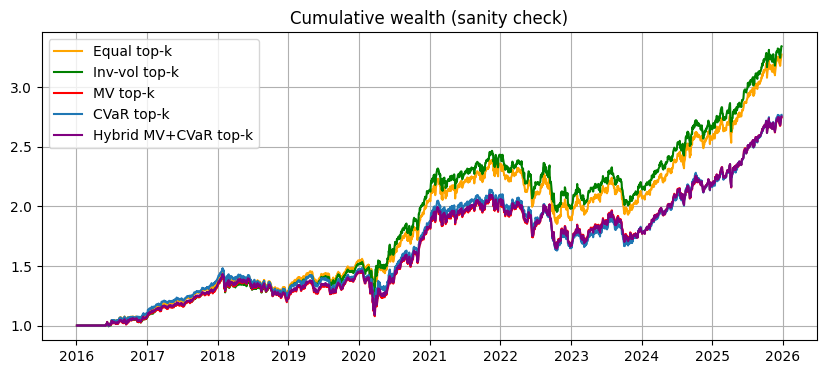

In [52]:
# Cell 7 — Quick sanity plots

def portfolio_return(W: pd.DataFrame, R: pd.DataFrame) -> pd.Series:
    # Simple sanity check only: applies weights indexed by date d to returns on date d.
    # Full execution timing should be handled in the backtest notebook.
    return (W * R).sum(axis=1)

pe = (1 + portfolio_return(W_eq_daily, R)).cumprod()
pv = (1 + portfolio_return(W_vp_daily, R)).cumprod()
pm = (1 + portfolio_return(W_mv_daily, R)).cumprod()
pc = (1 + portfolio_return(W_cvar_daily, R)).cumprod()
ph = (1 + portfolio_return(W_hyb_daily, R)).cumprod()

plt.figure(figsize=(10,4))
plt.plot(pe.index, pe.values, label="Equal top-k", color="orange")
plt.plot(pv.index, pv.values, label="Inv-vol top-k", color="green")
plt.plot(pm.index, pm.values, label="MV top-k", color="red")
plt.plot(pc.index, pc.values, label="CVaR top-k")
plt.plot(ph.index, ph.values, label="Hybrid MV+CVaR top-k", color="purple")
plt.title("Cumulative wealth (sanity check)")
plt.grid(True)
plt.legend()
plt.show()

In [44]:
# Cell 8 — Save outputs for backtest notebook

save_df(W_eq_daily.reset_index().rename(columns={"index":"date"}), "weights_eq_topk", DATA_DIR, fmt="parquet")
save_df(W_vp_daily.reset_index().rename(columns={"index":"date"}), "weights_invvol_topk", DATA_DIR, fmt="parquet")
save_df(W_mv_daily.reset_index().rename(columns={"index":"date"}), "weights_mv_topk", DATA_DIR, fmt="parquet")
save_df(W_cvar_daily.reset_index().rename(columns={"index":"date"}), "weights_cvar_topk", DATA_DIR, fmt="parquet")
save_df(W_hyb_daily.reset_index().rename(columns={"index":"date"}), "weights_hybrid_topk", DATA_DIR, fmt="parquet")

print("Saved: weights_eq_topk / weights_invvol_topk / weights_mv_topk / weights_cvar_topk / weights_hybrid_topk")

Saved: weights_eq_topk / weights_invvol_topk / weights_mv_topk / weights_cvar_topk / weights_hybrid_topk
